# 🤖 Task 1: Predict Restaurant Ratings
**Cognifyz Technologies — Machine Learning Internship**

---
**Objective:** Build a machine learning model to predict the aggregate rating of a restaurant based on other features.

**Steps:**
1. Preprocess the dataset by handling missing values, encoding categorical variables, and splitting into train/test sets.
2. Select a regression algorithm (e.g., linear regression, decision tree regression) and train it.
3. Evaluate using regression metrics (e.g., Mean Squared Error, R-squared).
4. Interpret results and analyze the most influential features affecting restaurant ratings.

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

os.makedirs('plots', exist_ok=True)
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

print('✅ Libraries loaded successfully!')

✅ Libraries loaded successfully!


## 2. Load Dataset

In [2]:
df = pd.read_csv('Dataset .csv')
print(f'Dataset Shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
df.head()

Dataset Shape: 9,551 rows × 21 columns


,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


## 3. Step 1 — Preprocess the Dataset

In [3]:
# 3a. Handle Missing Values
print('=== Missing Values Before Cleaning ===')
print(df.isnull().sum()[df.isnull().sum() > 0])

df['Cuisines'] = df['Cuisines'].fillna('Unknown')

print(f'\nMissing values after cleaning: {df.isnull().sum().sum()}')
print('✅ Missing values handled.')

=== Missing Values Before Cleaning ===
Cuisines    9
dtype: int64

Missing values after cleaning: 0
✅ Missing values handled.


In [4]:
# 3b. Encode Categorical Variables

# Binary columns: Yes/No → 1/0
binary_cols = ['Has Table booking', 'Has Online delivery', 'Is delivering now', 'Switch to order menu']
for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})
print('✅ Binary columns encoded (Yes→1, No→0)')

# City: top 20 cities, rest = 'Other'
top_cities = df['City'].value_counts().head(20).index
df['City_enc'] = df['City'].apply(lambda x: x if x in top_cities else 'Other')
le_city = LabelEncoder()
df['City_enc'] = le_city.fit_transform(df['City_enc'])
print('✅ City column label-encoded')

# Country Code: label encode
le_country = LabelEncoder()
df['Country_enc'] = le_country.fit_transform(df['Country Code'].astype(str))
print('✅ Country Code label-encoded')

# Number of cuisines per restaurant
df['Cuisine_count'] = df['Cuisines'].str.split(', ').apply(len)
print('✅ Cuisine count feature created')

✅ Binary columns encoded (Yes→1, No→0)
✅ City column label-encoded
✅ Country Code label-encoded
✅ Cuisine count feature created


In [5]:
# 3c. Feature Selection & Train/Test Split

features = [
    'Average Cost for two',
    'Price range',
    'Votes',
    'Has Table booking',
    'Has Online delivery',
    'Is delivering now',
    'City_enc',
    'Country_enc',
    'Cuisine_count'
]

# Use only rated restaurants (Aggregate rating > 0)
model_df = df[df['Aggregate rating'] > 0].copy()
print(f'Rated restaurants for modeling: {len(model_df):,}')

X = model_df[features]
y = model_df['Aggregate rating']

# 80/20 train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'\nTrain set : {len(X_train):,} samples')
print(f'Test set  : {len(X_test):,} samples')

# Scale features (for linear models)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print('✅ Data split into training and testing sets.')

Rated restaurants for modeling: 7,403

Train set : 5,922 samples
Test set  : 1,481 samples
✅ Data split into training and testing sets.


## 4. Step 2 — Select & Train Regression Algorithms

In [6]:
# Train multiple regression models
models = {
    'Linear Regression'  : (LinearRegression(), True),
    'Ridge Regression'   : (Ridge(alpha=1.0), True),
    'Decision Tree'      : (DecisionTreeRegressor(max_depth=8, random_state=42), False),
    'Random Forest'      : (RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1), False),
    'Gradient Boosting'  : (GradientBoostingRegressor(n_estimators=100, max_depth=5, random_state=42), False)
}

results = {}
print('Training models...')
print('-' * 70)

for name, (model, use_scaled) in models.items():
    Xtr = X_train_sc if use_scaled else X_train
    Xte = X_test_sc  if use_scaled else X_test

    model.fit(Xtr, y_train)
    y_pred = model.predict(Xte)

    mse  = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_test, y_pred)
    r2   = r2_score(y_test, y_pred)

    results[name] = {'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'R²': r2,
                     'model': model, 'y_pred': y_pred, 'scaled': use_scaled}
    print(f'{name:22s} | RMSE={rmse:.4f} | MAE={mae:.4f} | R²={r2:.4f}')

print('-' * 70)
print('✅ All models trained!')

Training models...
----------------------------------------------------------------------
Linear Regression      | RMSE=0.4363 | MAE=0.3420 | R²=0.3845
Ridge Regression       | RMSE=0.4363 | MAE=0.3420 | R²=0.3845
Decision Tree          | RMSE=0.3628 | MAE=0.2697 | R²=0.5744
Random Forest          | RMSE=0.3535 | MAE=0.2611 | R²=0.5959
Gradient Boosting      | RMSE=0.3478 | MAE=0.2576 | R²=0.6089
----------------------------------------------------------------------
✅ All models trained!


## 5. Step 3 — Evaluate Using Regression Metrics

In [7]:
# Results table
results_df = pd.DataFrame({
    name: {'MSE': v['MSE'], 'RMSE': v['RMSE'], 'MAE': v['MAE'], 'R²': v['R²']}
    for name, v in results.items()
}).T.round(4)

print('=== MODEL EVALUATION RESULTS ===')
display(results_df.sort_values('R²', ascending=False).style
        .background_gradient(subset=['R²'], cmap='Greens')
        .background_gradient(subset=['RMSE', 'MAE'], cmap='Reds_r'))

=== MODEL EVALUATION RESULTS ===


,MSE,RMSE,MAE,R²
Gradient Boosting,0.121000,0.347800,0.257600,0.608900
Random Forest,0.125000,0.353500,0.261100,0.595900
Decision Tree,0.131600,0.362800,0.269700,0.574400
Linear Regression,0.190400,0.436300,0.342000,0.384500
Ridge Regression,0.190400,0.436300,0.342000,0.384500


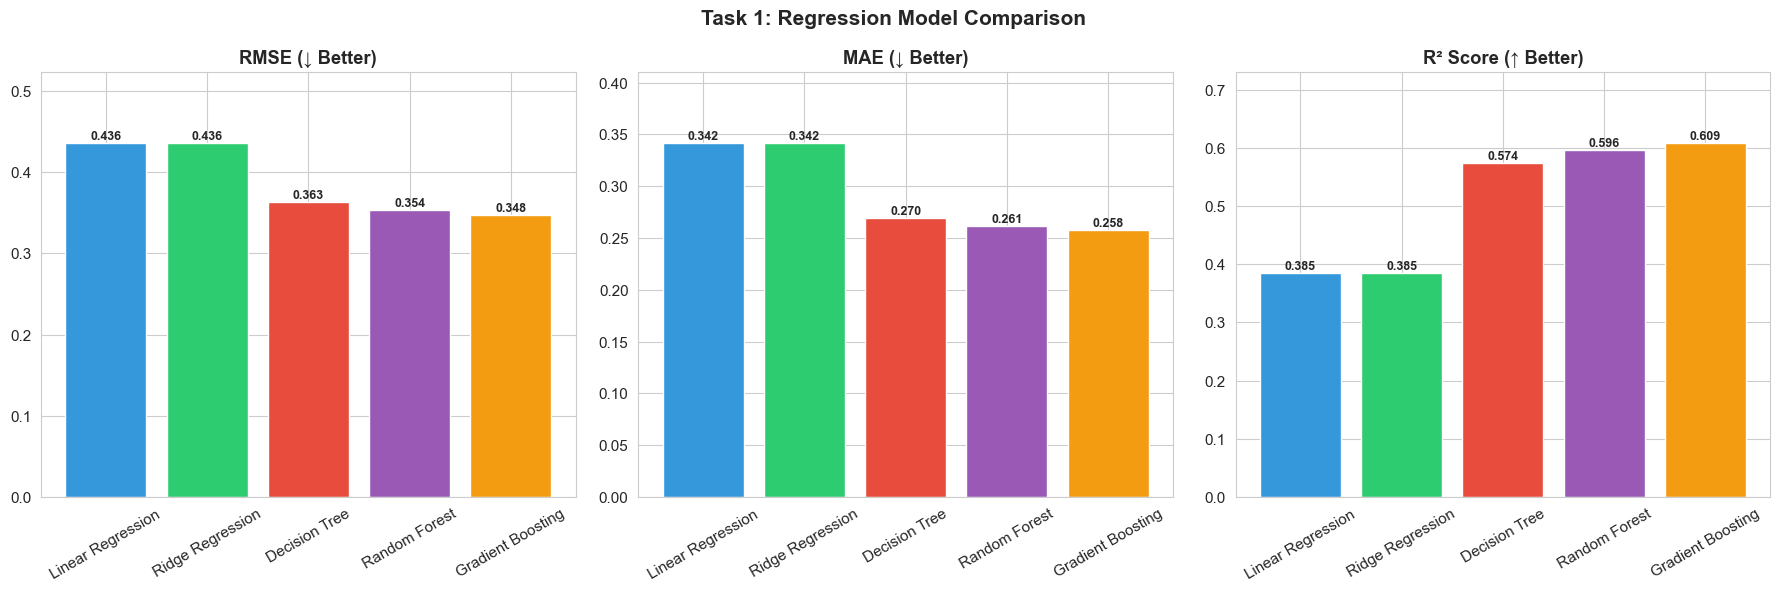

In [8]:
# Metric comparison bar charts
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
model_names = list(results.keys())
palette = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6', '#f39c12']

metrics = [('RMSE', 'RMSE (↓ Better)', 'Reds'), ('MAE', 'MAE (↓ Better)', 'Oranges'), ('R²', 'R² Score (↑ Better)', 'Greens')]

for ax, (metric, title, cmap) in zip(axes, metrics):
    vals = [results[m][metric] for m in model_names]
    bars = ax.bar(model_names, vals, color=palette, edgecolor='white')
    ax.set_title(title, fontweight='bold')
    ax.tick_params(axis='x', rotation=30)
    ax.set_ylim(0, max(vals) * 1.2)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(vals)*0.01,
                f'{val:.3f}', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Task 1: Regression Model Comparison', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/task1_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

🏆 Best Model: Gradient Boosting
   RMSE : 0.3478
   MAE  : 0.2576
   R²   : 0.6089


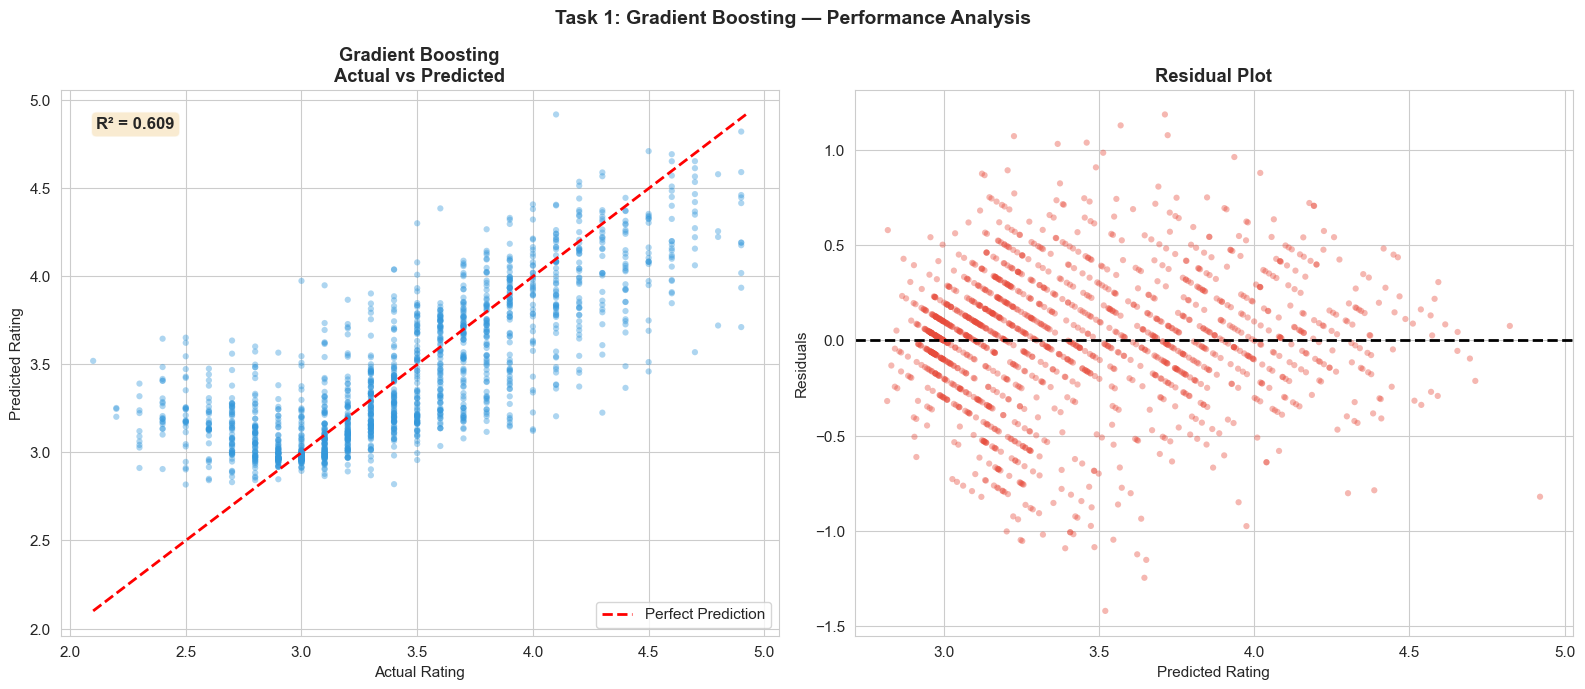

In [9]:
# Best model — Actual vs Predicted + Residuals
best_name = max(results, key=lambda k: results[k]['R²'])
best = results[best_name]
y_pred_best = best['y_pred']

print(f'🏆 Best Model: {best_name}')
print(f'   RMSE : {best["RMSE"]:.4f}')
print(f'   MAE  : {best["MAE"]:.4f}')
print(f'   R²   : {best["R²"]:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Actual vs Predicted
axes[0].scatter(y_test, y_pred_best, alpha=0.4, color='#3498db', s=20, edgecolors='none')
lims = [min(y_test.min(), y_pred_best.min()), max(y_test.max(), y_pred_best.max())]
axes[0].plot(lims, lims, 'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Rating')
axes[0].set_ylabel('Predicted Rating')
axes[0].set_title(f'{best_name}\nActual vs Predicted', fontweight='bold')
axes[0].legend()
axes[0].text(0.05, 0.95, f'R² = {best["R²"]:.3f}', transform=axes[0].transAxes,
            fontsize=12, fontweight='bold', va='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.6))

# Residual plot
residuals = y_test.values - y_pred_best
axes[1].scatter(y_pred_best, residuals, alpha=0.4, color='#e74c3c', s=20, edgecolors='none')
axes[1].axhline(0, color='black', lw=2, linestyle='--')
axes[1].set_xlabel('Predicted Rating')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Residual Plot', fontweight='bold')

plt.suptitle(f'Task 1: {best_name} — Performance Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/task1_actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
# 5-Fold Cross-Validation on best model
best_model_obj = best['model']
best_X = X_train_sc if best['scaled'] else X_train

cv_scores = cross_val_score(best_model_obj, X if not best['scaled'] else scaler.transform(X), y,
                            cv=5, scoring='r2')
print(f'=== 5-Fold Cross-Validation ({best_name}) ===')
for i, s in enumerate(cv_scores, 1):
    print(f'  Fold {i}: R² = {s:.4f}')
print(f'  Mean R²: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

=== 5-Fold Cross-Validation (Gradient Boosting) ===
  Fold 1: R² = 0.4321
  Fold 2: R² = 0.4861
  Fold 3: R² = 0.4022
  Fold 4: R² = 0.3965
  Fold 5: R² = 0.5321
  Mean R²: 0.4498 ± 0.0520


## 6. Step 4 — Interpret Results & Most Influential Features

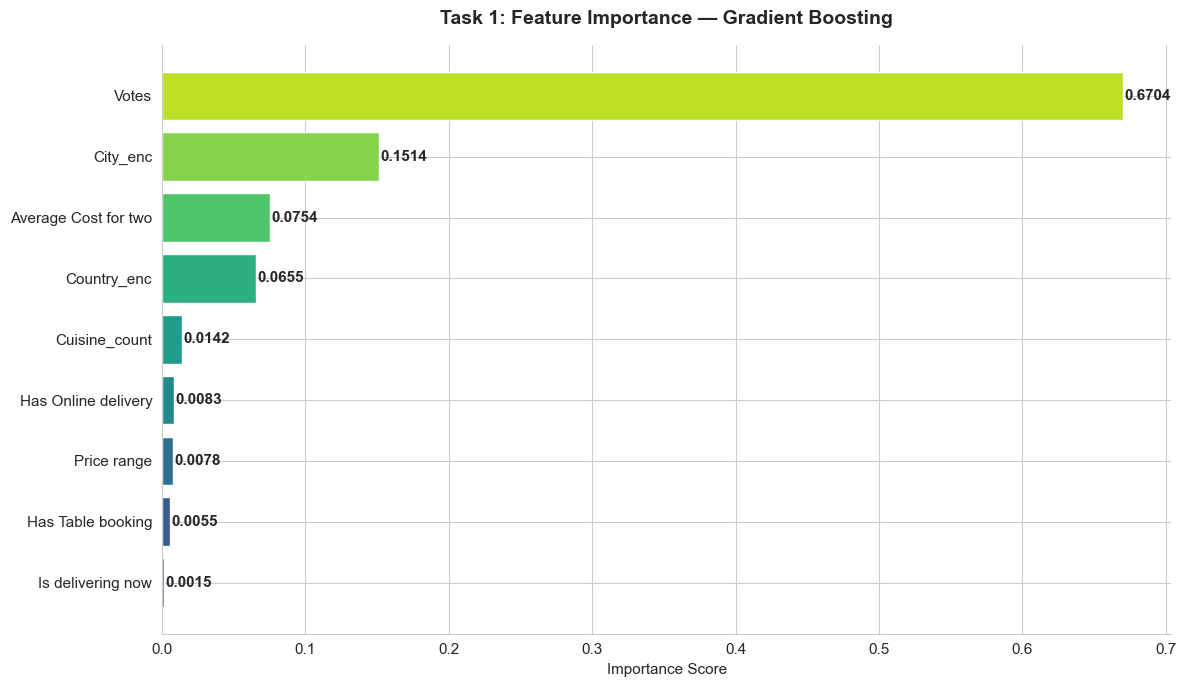


📊 Most Influential Features:
  Votes                    : 0.6704  ███████████████████████████████████████████████████████████████████
  City_enc                 : 0.1514  ███████████████
  Average Cost for two     : 0.0754  ███████
  Country_enc              : 0.0655  ██████
  Cuisine_count            : 0.0142  █
  Has Online delivery      : 0.0083  
  Price range              : 0.0078  
  Has Table booking        : 0.0055  
  Is delivering now        : 0.0015  


In [11]:
# Feature importance for tree-based best model
if hasattr(best_model_obj, 'feature_importances_'):
    feat_imp = pd.DataFrame({
        'Feature': features,
        'Importance': best_model_obj.feature_importances_
    }).sort_values('Importance', ascending=True)

    fig, ax = plt.subplots(figsize=(12, 7))
    colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(features)))
    bars = ax.barh(feat_imp['Feature'], feat_imp['Importance'], color=colors, edgecolor='white')
    for bar, val in zip(bars, feat_imp['Importance']):
        ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=11, fontweight='bold')
    ax.set_title(f'Task 1: Feature Importance — {best_name}', fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel('Importance Score')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.savefig('plots/task1_feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()

    print('\n📊 Most Influential Features:')
    for _, row in feat_imp.sort_values('Importance', ascending=False).iterrows():
        bar = '█' * int(row['Importance'] * 100)
        print(f'  {row["Feature"]:25s}: {row["Importance"]:.4f}  {bar}')

else:
    # Linear model — show coefficients
    coef_df = pd.DataFrame({'Feature': features,
                            'Coefficient': np.abs(best_model_obj.coef_)}).sort_values('Coefficient', ascending=True)
    fig, ax = plt.subplots(figsize=(12, 7))
    ax.barh(coef_df['Feature'], coef_df['Coefficient'], color='#3498db')
    ax.set_title(f'Task 1: Feature |Coefficients| — {best_name}', fontweight='bold')
    ax.set_xlabel('|Coefficient|')
    plt.tight_layout()
    plt.savefig('plots/task1_feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()

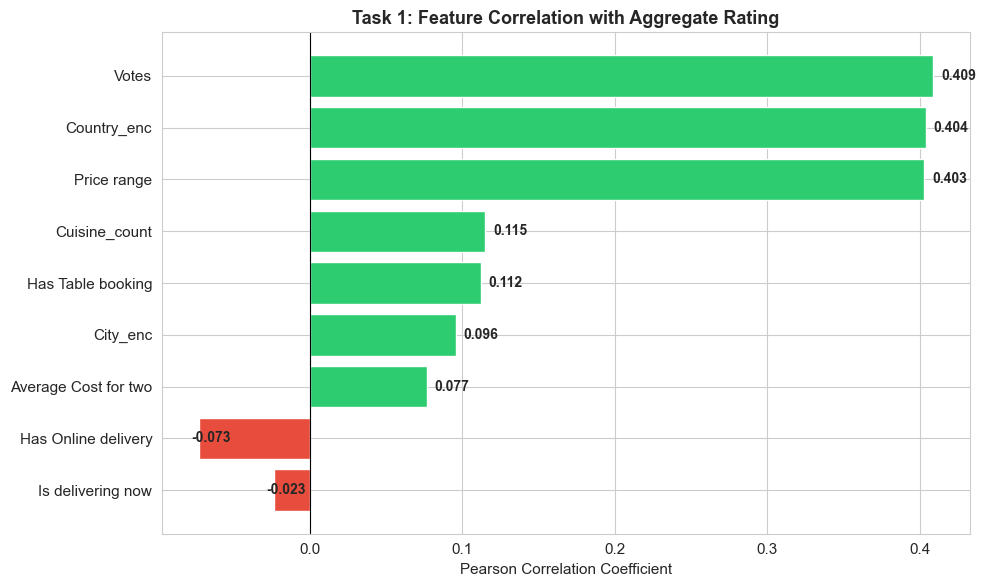

In [12]:
# Correlation heatmap — feature vs target
corr_data = model_df[features + ['Aggregate rating']].corr()
target_corr = corr_data['Aggregate rating'].drop('Aggregate rating').sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in target_corr.values]
bars = ax.barh(target_corr.index[::-1], target_corr.values[::-1], color=colors[::-1], edgecolor='white')
ax.axvline(0, color='black', lw=0.8)
ax.set_title('Task 1: Feature Correlation with Aggregate Rating', fontsize=13, fontweight='bold')
ax.set_xlabel('Pearson Correlation Coefficient')
for bar, val in zip(bars, target_corr.values[::-1]):
    offset = 0.005 if val >= 0 else -0.005
    ax.text(bar.get_width() + offset, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/task1_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Summary

In [13]:
print('=' * 65)
print('    TASK 1 SUMMARY — PREDICT RESTAURANT RATINGS')
print('=' * 65)
print(f'\n📌 Dataset        : {len(df):,} restaurants | {len(model_df):,} rated')
print(f'📌 Features Used  : {len(features)}')
print(f'📌 Train / Test   : {len(X_train):,} / {len(X_test):,}')
print(f'📌 Models Trained : {len(models)}')
print()
print('📊 Model Rankings (by R²):')
for name, v in sorted(results.items(), key=lambda x: x[1]['R²'], reverse=True):
    marker = '🏆' if name == best_name else '  '
    print(f' {marker} {name:22s}: R²={v["R²"]:.4f}  RMSE={v["RMSE"]:.4f}')
print()
print(f'🏆 Best Model     : {best_name}')
print(f'   R² Score       : {best["R²"]:.4f}')
print(f'   RMSE           : {best["RMSE"]:.4f}')
print(f'   CV R² (5-fold) : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
print()
print('🔑 Key Insight: Votes & Price Range are the most influential')
print('   features for predicting restaurant ratings.')
print('=' * 65)
print('✅ Task 1 Complete!')

    TASK 1 SUMMARY — PREDICT RESTAURANT RATINGS

📌 Dataset        : 9,551 restaurants | 7,403 rated
📌 Features Used  : 9
📌 Train / Test   : 5,922 / 1,481
📌 Models Trained : 5

📊 Model Rankings (by R²):
 🏆 Gradient Boosting     : R²=0.6089  RMSE=0.3478
    Random Forest         : R²=0.5959  RMSE=0.3535
    Decision Tree         : R²=0.5744  RMSE=0.3628
    Linear Regression     : R²=0.3845  RMSE=0.4363
    Ridge Regression      : R²=0.3845  RMSE=0.4363

🏆 Best Model     : Gradient Boosting
   R² Score       : 0.6089
   RMSE           : 0.3478
   CV R² (5-fold) : 0.4498 ± 0.0520

🔑 Key Insight: Votes & Price Range are the most influential
   features for predicting restaurant ratings.
✅ Task 1 Complete!
